# Visualise Scores for LLM-vs-LMM Experiments

## 1. Imports & Plot Utils 

In [2]:
# === SETUP ===

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# show full tables if you print heads
pd.set_option("display.max_columns", 200)

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

LLM2_PATH = BASE_DIR / "data" / "scores" / "with_cat_persona_20260203_162120__inv_none__per_turn.parquet"
LLM1_PATH    = BASE_DIR / "data" / "scores" / "with_cat_persona_20260203_162120__inv_none__llm1_per_turn.parquet"

assert LLM2_PATH.exists(), f"Missing: {LLM2_PATH}"
assert LLM1_PATH.exists(), f"Missing: {LLM1_PATH}"

df_a = pd.read_parquet(LLM2_PATH)
df_u = pd.read_parquet(LLM1_PATH)

print("LLM2 DF:", df_a.shape, df_a.columns.tolist())
print("LLM1 DF:", df_u.shape, df_u.columns.tolist())

display(df_a.head(3))
display(df_u.head(3))

LLM2 DF: (112, 8) ['conversation_idx', 'persona_id', 'base_persona_id', 'style_id', 'assistant_turn_idx', 'avg_nll', 'num_tokens', 'ppl']
LLM1 DF: (112, 8) ['conversation_idx', 'persona_id', 'base_persona_id', 'style_id', 'user_turn_idx', 'avg_nll', 'num_tokens', 'ppl']


,conversation_idx,persona_id,base_persona_id,style_id,assistant_turn_idx,avg_nll,num_tokens,ppl
0,0,bp_traveler__st_skeptical__inv_none,bp_traveler,st_skeptical,0,1.011338,202,2.749278
1,0,bp_traveler__st_skeptical__inv_none,bp_traveler,st_skeptical,1,1.394490,202,4.032915
2,0,bp_traveler__st_skeptical__inv_none,bp_traveler,st_skeptical,2,1.233138,202,3.431983


,conversation_idx,persona_id,base_persona_id,style_id,user_turn_idx,avg_nll,num_tokens,ppl
0,0,bp_traveler__st_skeptical__inv_none,bp_traveler,st_skeptical,0,2.739064,54,15.472488
1,0,bp_traveler__st_skeptical__inv_none,bp_traveler,st_skeptical,1,2.102620,18,8.187594
2,0,bp_traveler__st_skeptical__inv_none,bp_traveler,st_skeptical,2,2.135650,26,8.462543


In [3]:
# === QUICK SANITY CHECKS ===

def sanity(df: pd.DataFrame, turn_col: str, name: str):
    print(f"\n--- {name} ---")
    print("unique base_persona_id:", df["base_persona_id"].nunique(), sorted(df["base_persona_id"].unique()))
    print("unique style_id:", df["style_id"].nunique(), sorted(df["style_id"].unique()))
    print("turn_col:", turn_col, "min/max:", int(df[turn_col].min()), int(df[turn_col].max()))
    print("avg_nll min/max:", float(df["avg_nll"].min()), float(df["avg_nll"].max()))

sanity(df_a, "assistant_turn_idx", "ASSISTANT")
sanity(df_u, "user_turn_idx", "LLM1/USER")


--- ASSISTANT ---
unique base_persona_id: 3 ['bp_career_builder', 'bp_tech_starter', 'bp_traveler']
unique style_id: 5 ['st_blunt', 'st_formal', 'st_rambler', 'st_skeptical', 'st_warm']
turn_col: assistant_turn_idx min/max: 0 7
avg_nll min/max: 0.38698601722717285 1.606242299079895

--- LLM1/USER ---
unique base_persona_id: 3 ['bp_career_builder', 'bp_tech_starter', 'bp_traveler']
unique style_id: 5 ['st_blunt', 'st_formal', 'st_rambler', 'st_skeptical', 'st_warm']
turn_col: user_turn_idx min/max: 0 7
avg_nll min/max: 0.32555723190307617 4.412234783172607


In [4]:
# === PLOTTING HELPERS ===

def _prep_mean_by_turn(
    df: pd.DataFrame,
    turn_col: str,
    line_col: str,
) -> pd.DataFrame:
    """
    Returns a wide dataframe:
      index = turn_col
      columns = categories in line_col
      values = mean(avg_nll)
    Missing turn/category combos are NaN (matplotlib will break the line).
    """
    g = (
        df.groupby([turn_col, line_col], as_index=False)["avg_nll"]
          .mean()
          .rename(columns={"avg_nll": "mean_avg_nll"})
    )
    wide = g.pivot(index=turn_col, columns=line_col, values="mean_avg_nll").sort_index()
    return wide


def plot_panel(
    df: pd.DataFrame,
    *,
    panel_filter_col: str,
    panel_value: str,
    turn_col: str,
    line_col: str,
    title_prefix: str,
):
    """
    One figure for one panel_value.
    x = turn_col
    y = mean avg_nll
    multiple lines = line_col categories
    """
    sub = df[df[panel_filter_col] == panel_value].copy()
    if sub.empty:
        print(f"[skip] empty panel: {panel_filter_col}={panel_value}")
        return

    wide = _prep_mean_by_turn(sub, turn_col=turn_col, line_col=line_col)

    plt.figure(figsize=(10, 5))
    for col in wide.columns:
        plt.plot(wide.index, wide[col], marker="o", linewidth=2, label=str(col))

    plt.title(f"{title_prefix} | {panel_filter_col}={panel_value} | lines={line_col}")
    plt.xlabel("Turn index")
    plt.ylabel("Mean avg NLL")
    plt.xticks(wide.index)  # integer ticks for turns
    plt.grid(True, alpha=0.3)
    plt.legend(title=line_col, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## 2. Hidden Personas with Styles - NO Investigator

### 2.1. Assistant Turns

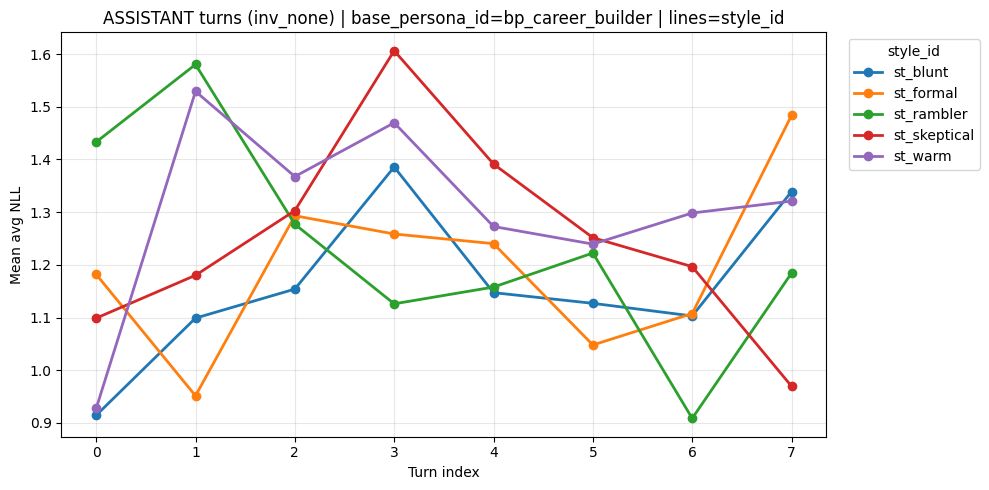

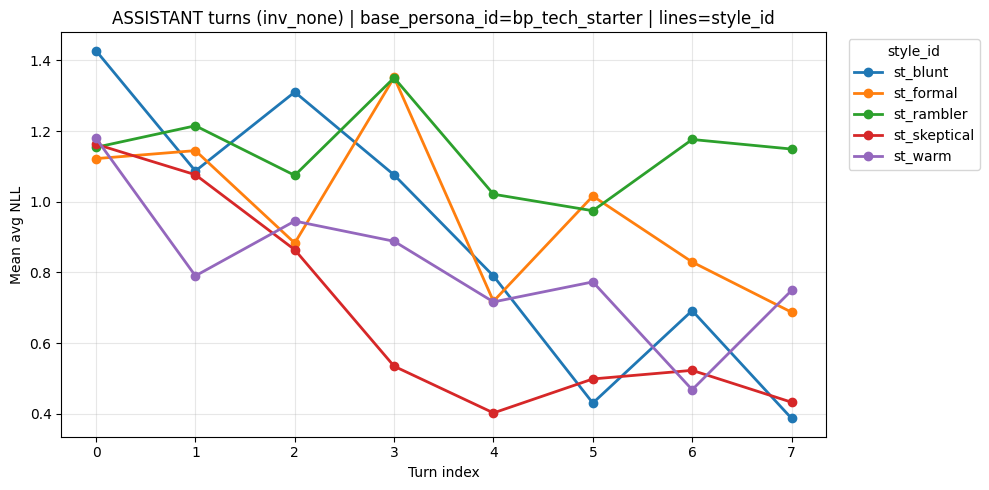

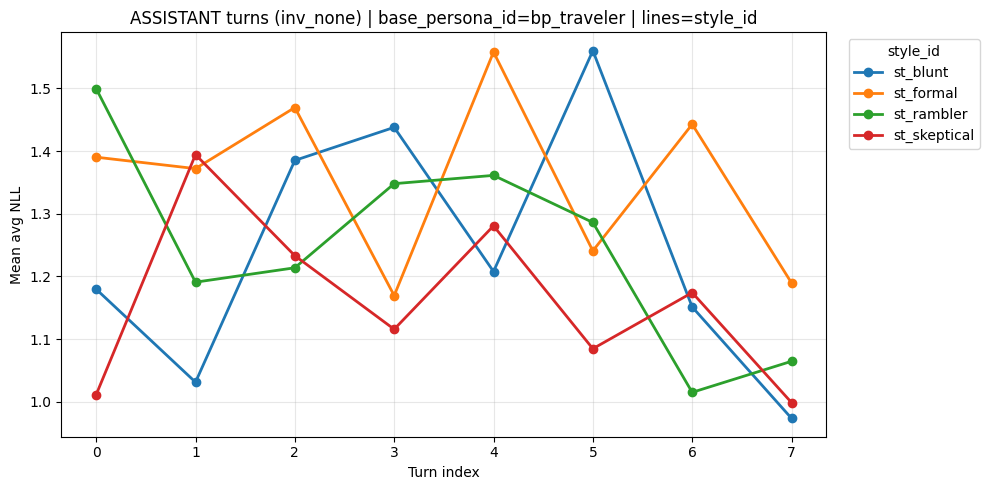

In [5]:
# === ASSISTANT: per base_persona (lines=style) ===

for bp in sorted(df_a["base_persona_id"].unique()):
    plot_panel(
        df_a,
        panel_filter_col="base_persona_id",
        panel_value=bp,
        turn_col="assistant_turn_idx",
        line_col="style_id",
        title_prefix="ASSISTANT turns (inv_none)",
    )

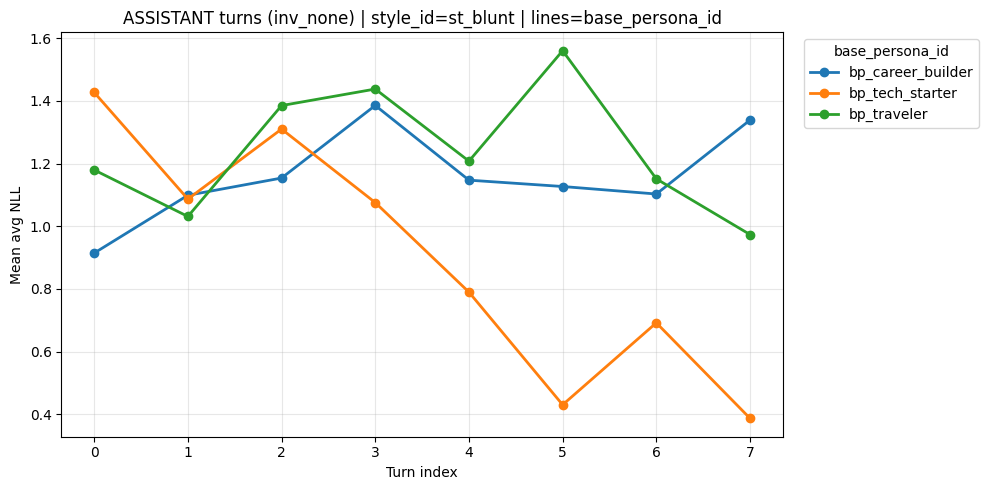

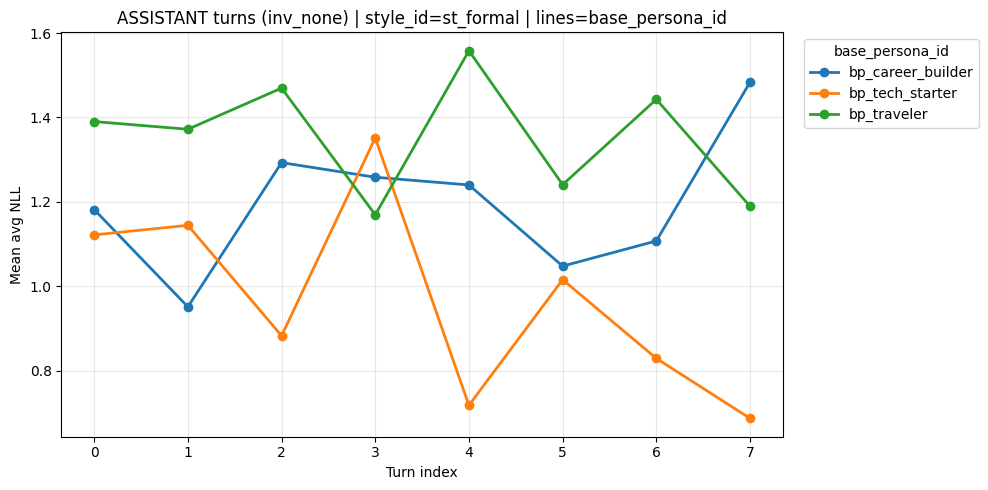

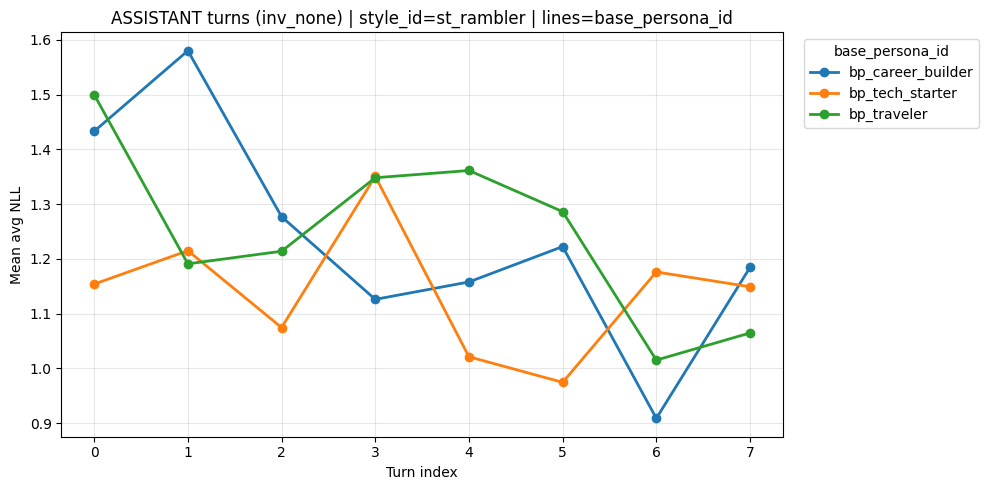

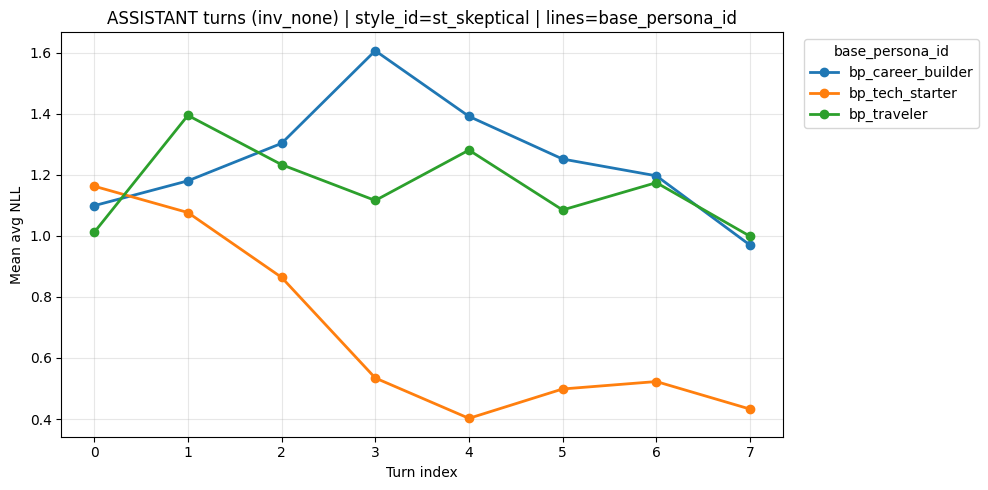

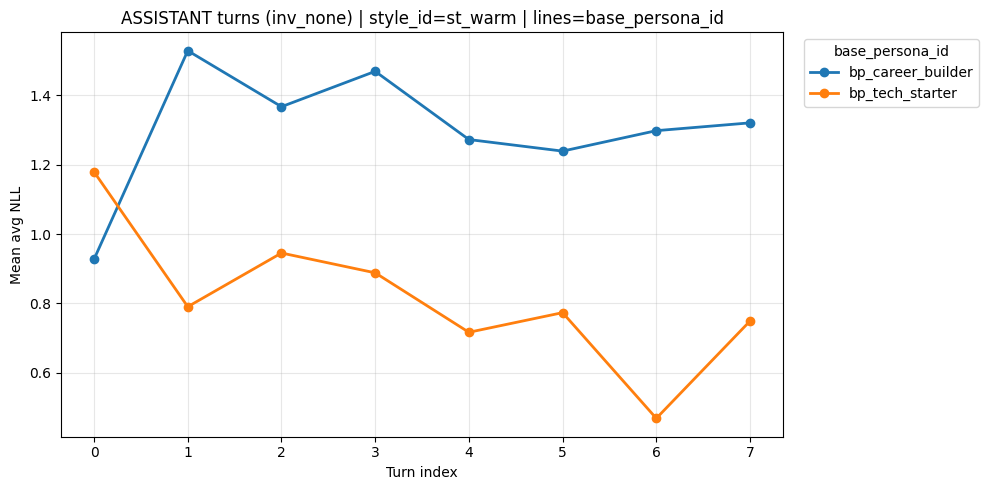

In [6]:
# === ASSISTANT: per style (lines=base_persona) ===

for st in sorted(df_a["style_id"].unique()):
    plot_panel(
        df_a,
        panel_filter_col="style_id",
        panel_value=st,
        turn_col="assistant_turn_idx",
        line_col="base_persona_id",
        title_prefix="ASSISTANT turns (inv_none)",
    )

### 2.2. User Turns

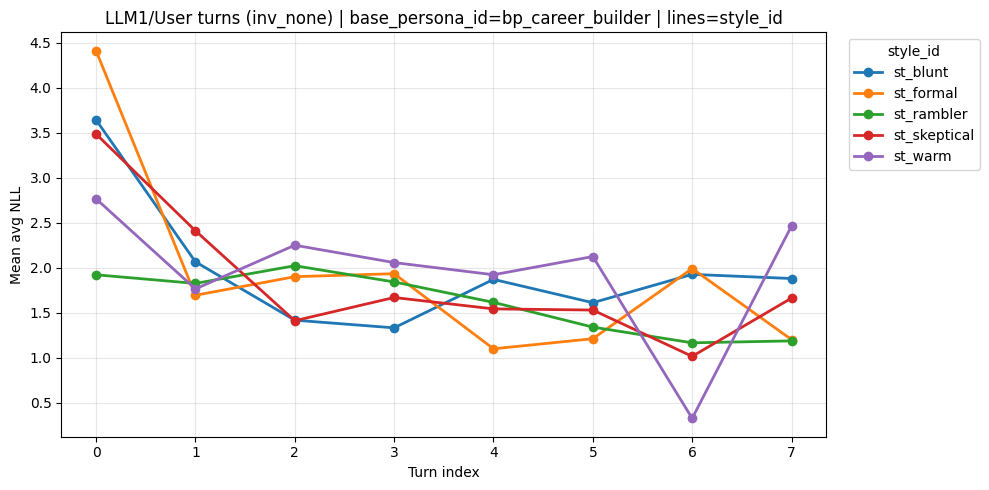

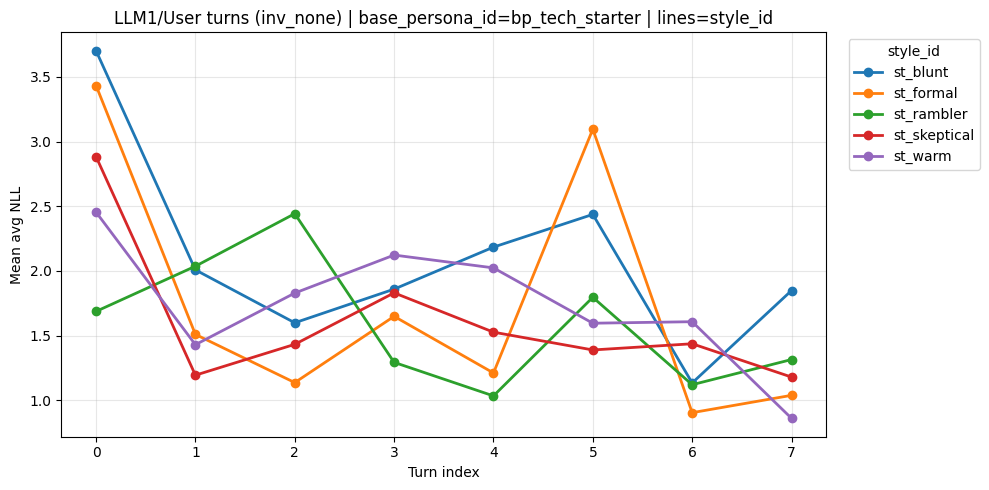

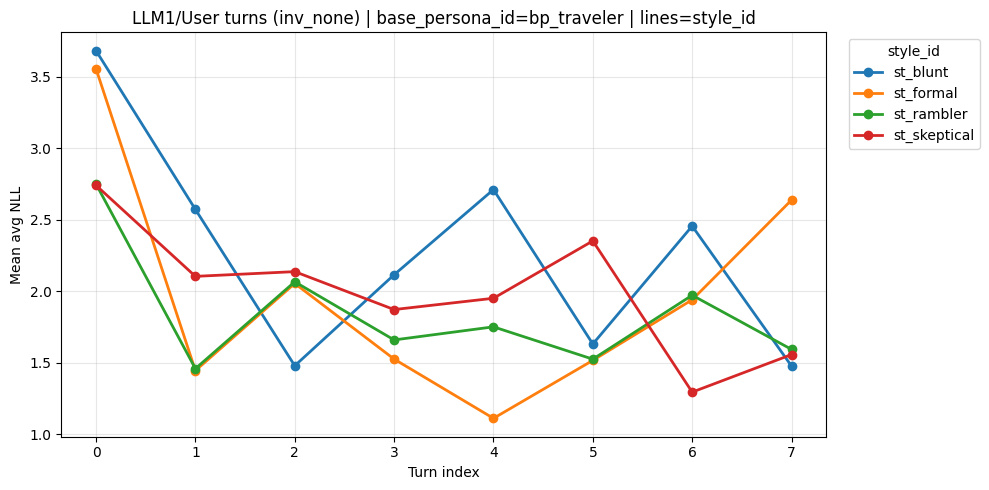

In [7]:
# === LLM1/USER: per base_persona (lines=style) ===

for bp in sorted(df_u["base_persona_id"].unique()):
    plot_panel(
        df_u,
        panel_filter_col="base_persona_id",
        panel_value=bp,
        turn_col="user_turn_idx",
        line_col="style_id",
        title_prefix="LLM1/User turns (inv_none)",
    )

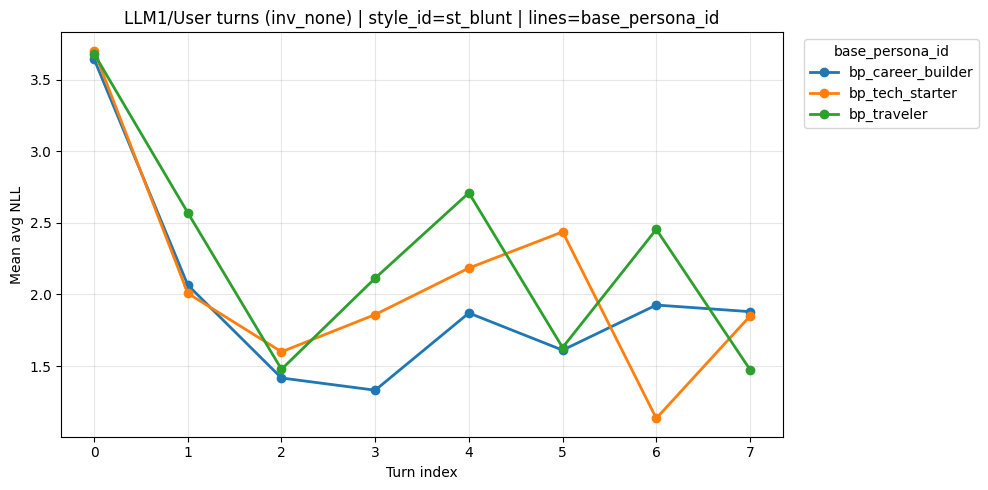

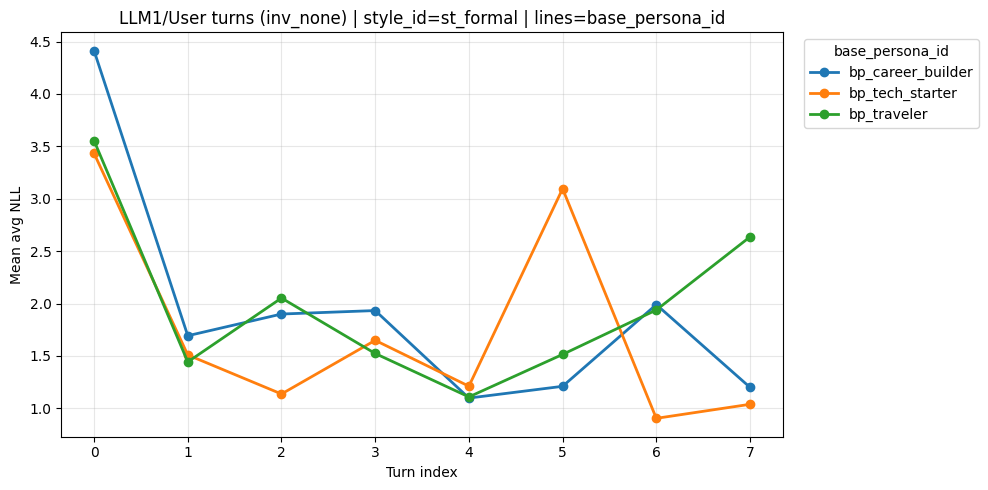

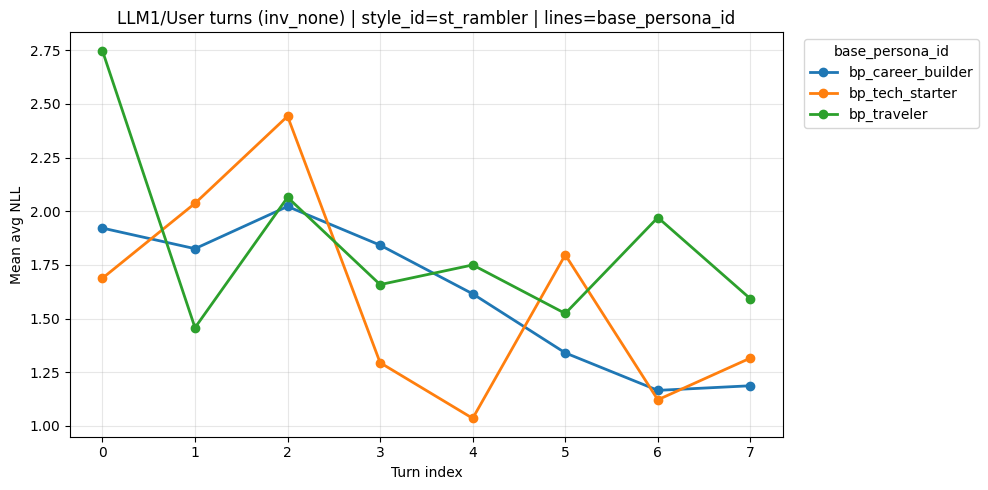

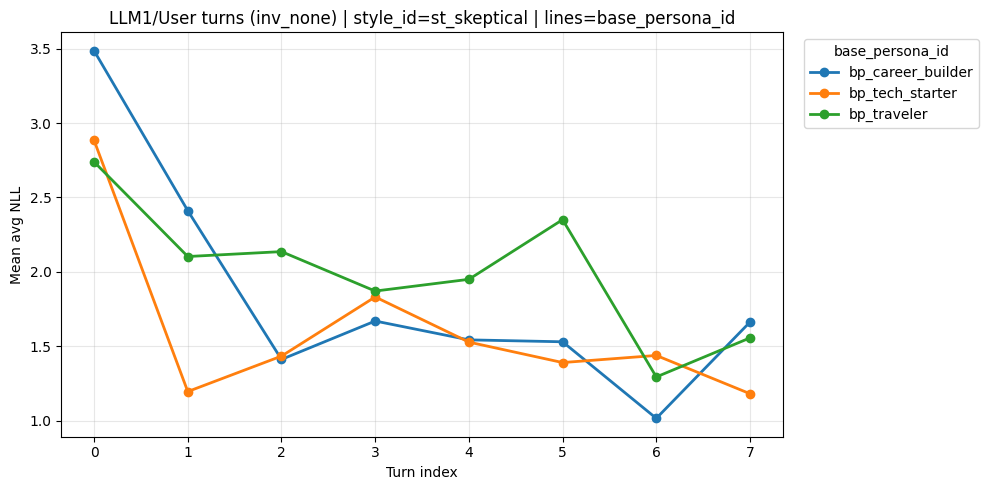

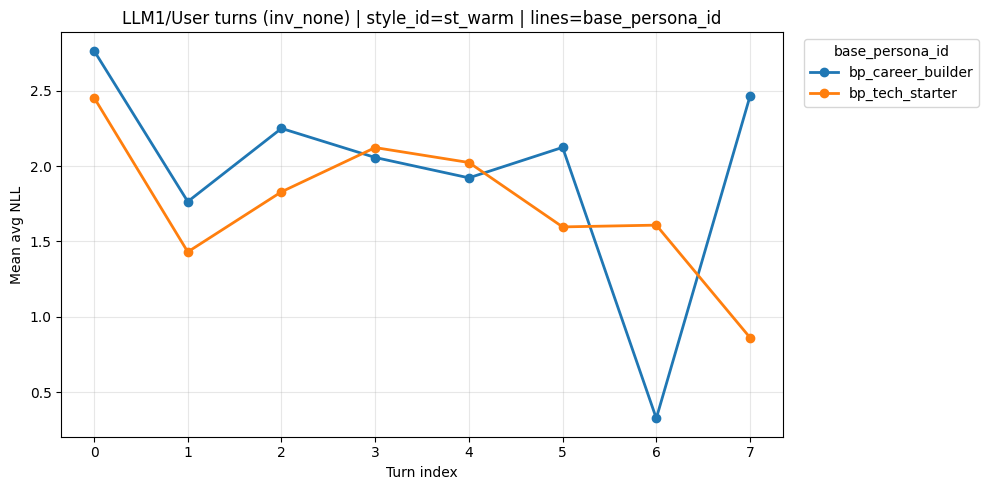

In [8]:
# === LLM1/USER: per style (lines=base_persona) ===

for st in sorted(df_u["style_id"].unique()):
    plot_panel(
        df_u,
        panel_filter_col="style_id",
        panel_value=st,
        turn_col="user_turn_idx",
        line_col="base_persona_id",
        title_prefix="LLM1/User turns (inv_none)",
    )